<a href="https://colab.research.google.com/github/Yash433-sp/-customer-churn-prediction/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/DA_P2/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
print("Data types:")
print(df.dtypes)

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [4]:
print("\nNull values:")
print(df.isnull().sum())


Null values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
print("\nBasic statistics:")
df.describe()


Basic statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
print("Churn value counts:")
print(df['Churn'].value_counts())

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [7]:
print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)


Churn percentage:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [8]:
cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
        'InternetService', 'Contract', 'PaymentMethod']

for col in cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
Contract: ['Month-to-month' 'One year' 'Two year']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("TotalCharges nulls after conversion:", df['TotalCharges'].isnull().sum())
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("TotalCharges dtype:", df['TotalCharges'].dtype)

TotalCharges nulls after conversion: 11
TotalCharges dtype: float64


/tmp/ipykernel_1506/586487533.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [10]:
df = df.drop(columns=['customerID'])
print("Dropped customerID column")
print("New shape:", df.shape)

Dropped customerID column
New shape: (7043, 20)


In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn value counts after conversion:")
print(df['Churn'].value_counts())

Churn value counts after conversion:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [12]:
binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'gender']
for col in binary_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].map({'Yes': 1, 'No': 0,
                               'Male': 1, 'Female': 0})

print("Binary columns converted!")
print(df[binary_cols].head())

Binary columns converted!
   Partner  Dependents  PhoneService  PaperlessBilling  gender
0        1           0             0                 1       0
1        0           0             1                 0       1
2        0           0             1                 1       1
3        0           0             0                 0       1
4        0           0             1                 1       0


In [13]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Remaining categorical columns:", cat_cols)

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("\nShape after encoding:", df.shape)

Remaining categorical columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Shape after encoding: (7043, 31)


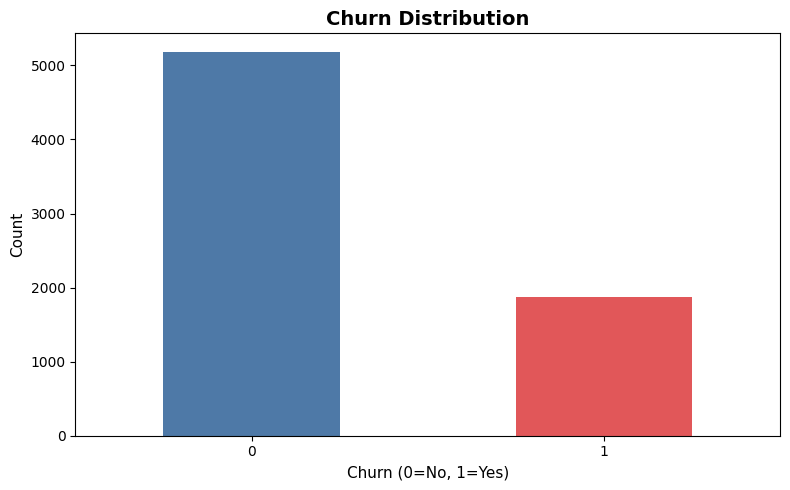

In [14]:
plt.figure(figsize=(8, 5))
df['Churn'].value_counts().plot(kind='bar', color=['#4e79a7', '#e15759'])
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn (0=No, 1=Yes)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

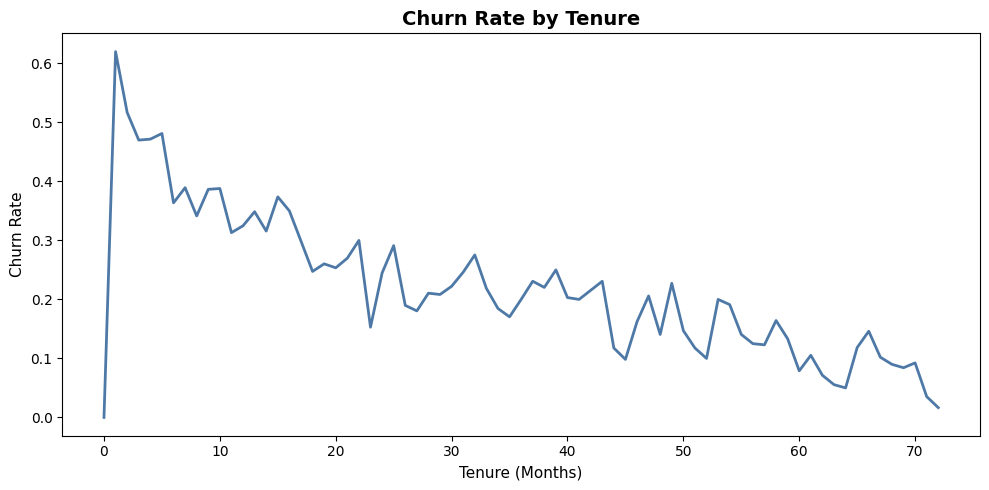

In [15]:
plt.figure(figsize=(10, 5))
df.groupby('tenure')['Churn'].mean().plot(kind='line',
                                          color='#4e79a7', linewidth=2)
plt.title('Churn Rate by Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)', fontsize=11)
plt.ylabel('Churn Rate', fontsize=11)
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

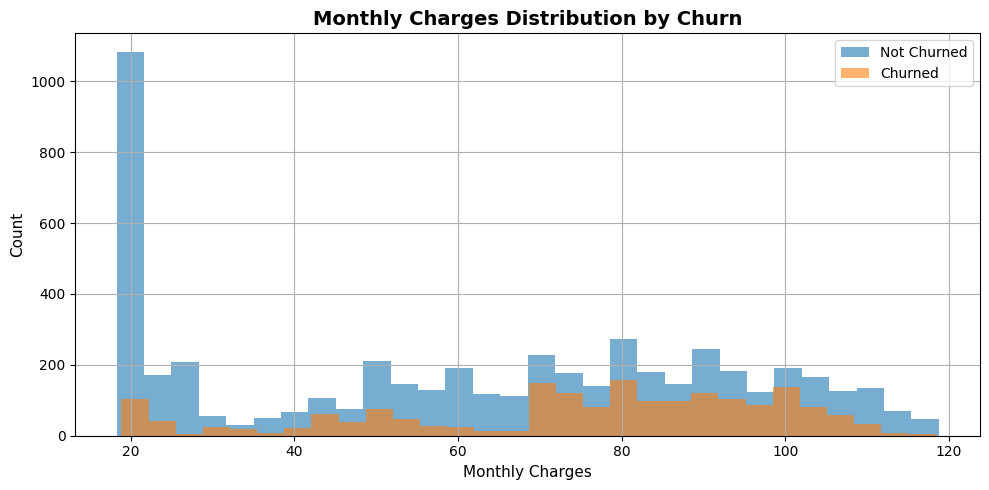

In [16]:
plt.figure(figsize=(10, 5))
df.groupby('Churn')['MonthlyCharges'].hist(alpha=0.6, bins=30)
plt.title('Monthly Charges Distribution by Churn',
          fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.legend(['Not Churned', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_charges.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1506/3232066531.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation.values, y=correlation.index,


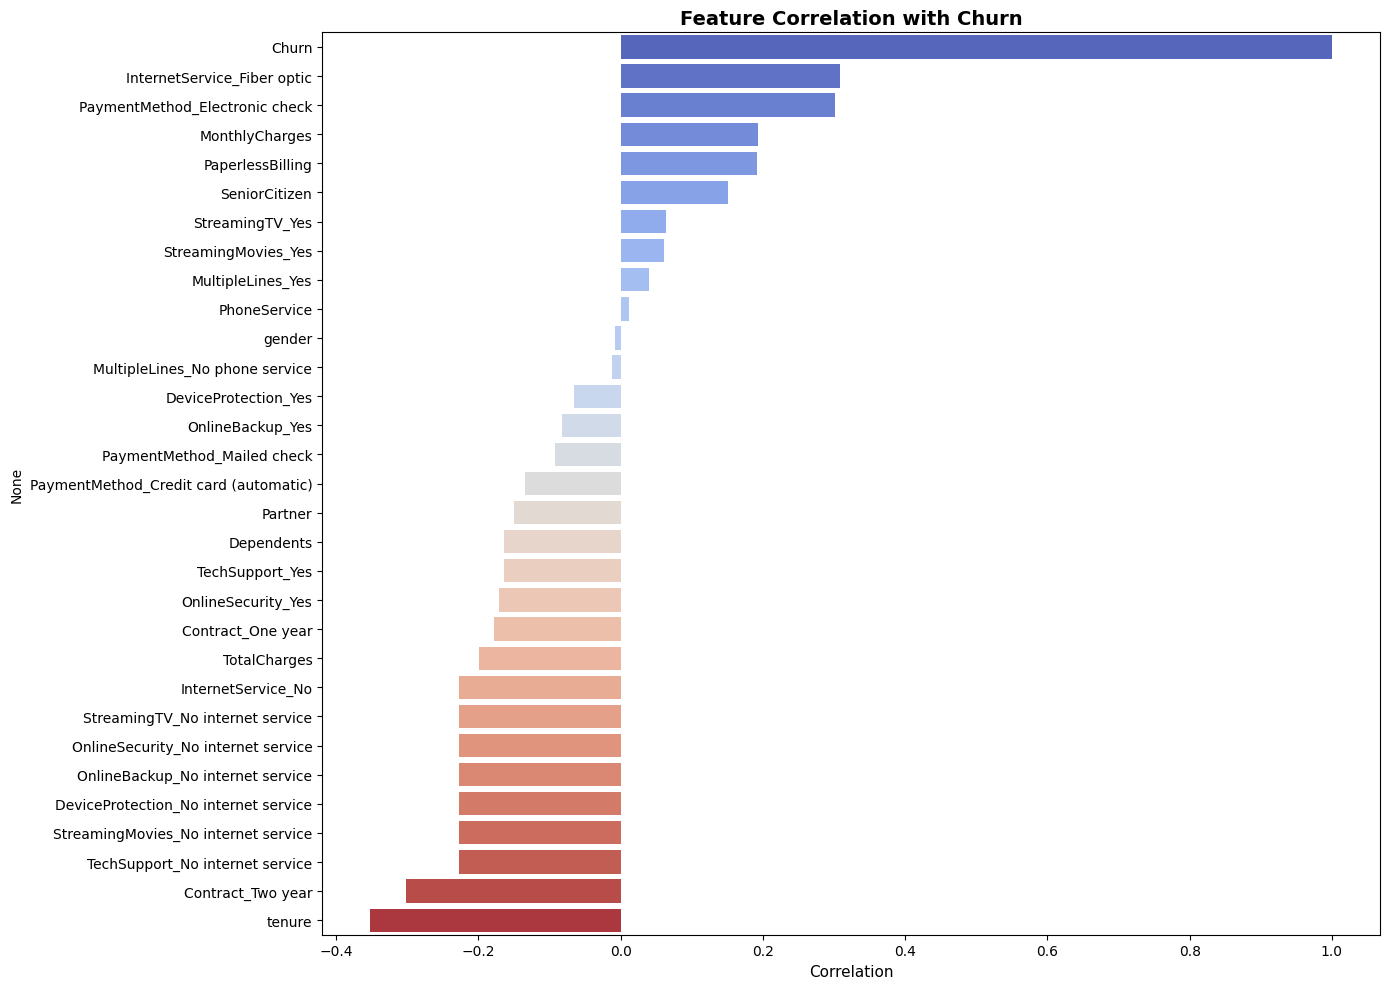

Top 5 factors that INCREASE churn:
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
Name: Churn, dtype: float64

Top 5 factors that DECREASE churn:
DeviceProtection_No internet service   -0.227890
StreamingMovies_No internet service    -0.227890
TechSupport_No internet service        -0.227890
Contract_Two year                      -0.302253
tenure                                 -0.352229
Name: Churn, dtype: float64


In [17]:
plt.figure(figsize=(14, 10))
correlation = df.corr()['Churn'].sort_values(ascending=False)

sns.barplot(x=correlation.values, y=correlation.index,
            palette='coolwarm')
plt.title('Feature Correlation with Churn',
          fontsize=14, fontweight='bold')
plt.xlabel('Correlation', fontsize=11)
plt.tight_layout()
plt.savefig('churn_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 factors that INCREASE churn:")
print(correlation[1:6])
print("\nTop 5 factors that DECREASE churn:")
print(correlation[-5:])

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nChurn distribution in training set:")
print(y_train.value_counts(normalize=True).round(3) * 100)

Training set size: (5634, 30)
Testing set size: (1409, 30)

Churn distribution in training set:
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print("Training set shape:", X_train_scaled.shape)

Features scaled successfully!
Training set shape: (5634, 30)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

print("Logistic Regression Results")
print(f"Accuracy: {accuracy_score(y_test, lr_predictions)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Results
Accuracy: 80.70%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Results")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Results
Accuracy: 78.71%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



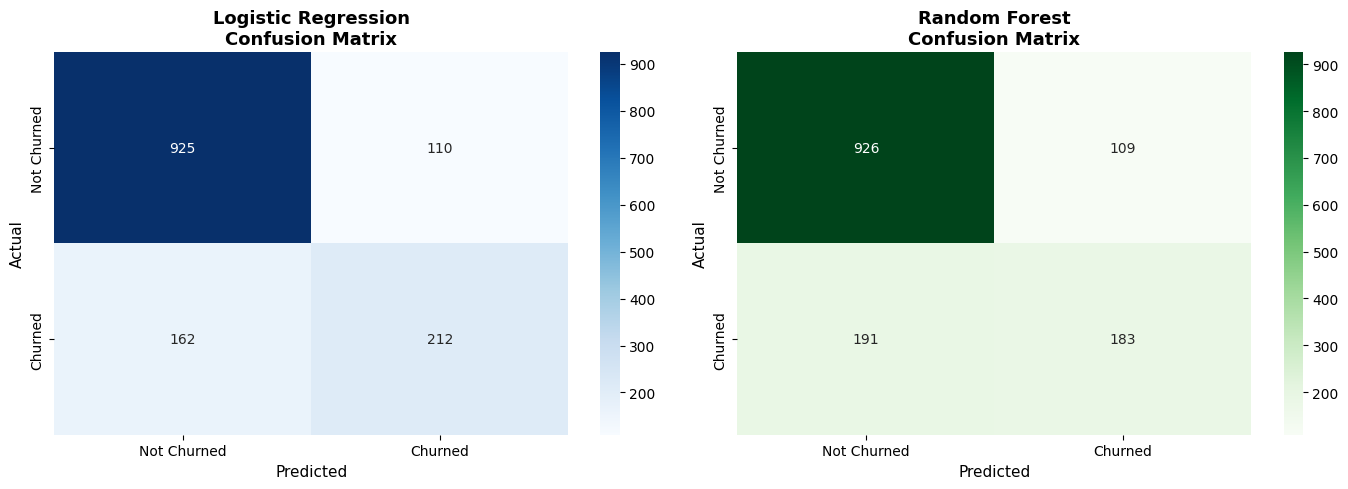

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression confusion matrix
sns.heatmap(confusion_matrix(y_test, lr_predictions),
            annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Logistic Regression\nConfusion Matrix',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Predicted', fontsize=11)
ax1.set_ylabel('Actual', fontsize=11)
ax1.set_xticklabels(['Not Churned', 'Churned'])
ax1.set_yticklabels(['Not Churned', 'Churned'])

# Random Forest confusion matrix
sns.heatmap(confusion_matrix(y_test, rf_predictions),
            annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Random Forest\nConfusion Matrix',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Predicted', fontsize=11)
ax2.set_ylabel('Actual', fontsize=11)
ax2.set_xticklabels(['Not Churned', 'Churned'])
ax2.set_yticklabels(['Not Churned', 'Churned'])

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

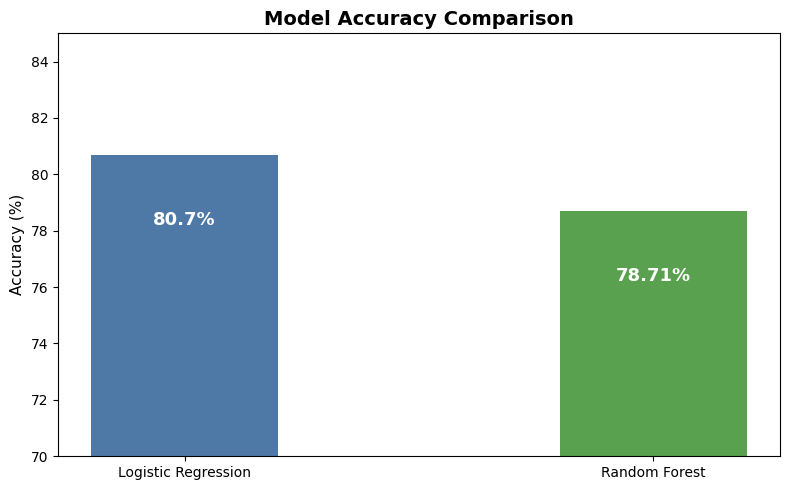

In [23]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [80.70, 78.71]
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#4e79a7', '#59a14f'], width=0.4)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 2,
             f'{acc}%', ha='center', va='top',
             fontsize=13, fontweight='bold', color='white')

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=11)
plt.ylim(70, 85)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1506/3017298334.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature',


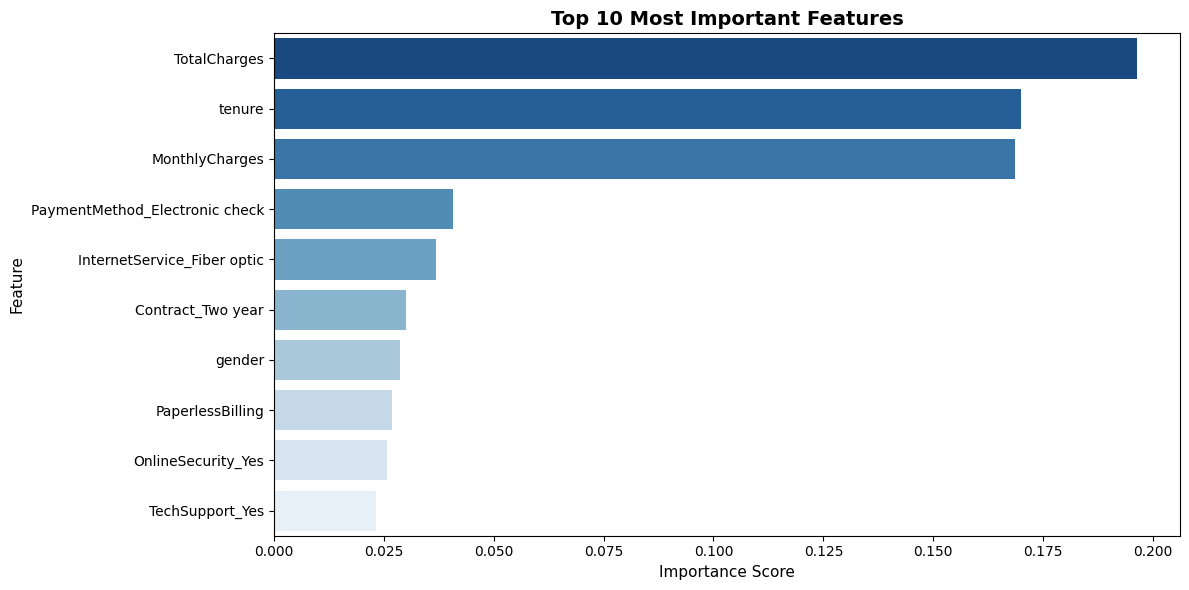

Top 5 most important features:
                       feature  importance
                  TotalCharges    0.196280
                        tenure    0.169860
                MonthlyCharges    0.168515
PaymentMethod_Electronic check    0.040664
   InternetService_Fiber optic    0.036985


In [24]:

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    'importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature',
            data=feature_importance, palette='Blues_r')
plt.title('Top 10 Most Important Features',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(feature_importance.head(5).to_string(index=False))